In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf


Images shape: (20, 64, 64, 3)
Labels shape: (20,)


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

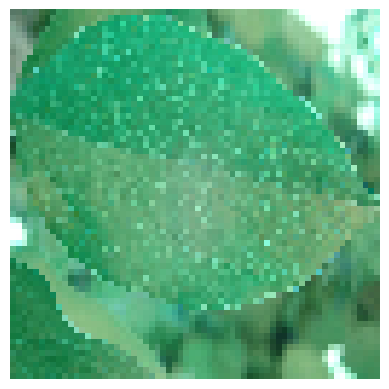

In [7]:
dataset_path = 'dataset'
categories = ['Class-1', 'Class-2']
data = []
labels = []
img_size = (64, 64)

for category in categories:
    folder_path = os.path.join(dataset_path, category)
    label = categories.index(category)
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.resize(img, img_size)
        data.append(img)
        labels.append(label)
x = np.array(data)/255.0
y = np.array(labels)
print("Images shape:", x.shape)
print("Labels shape:", y.shape)
plt.imshow(x[0])
plt.axis('off')

In [8]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Training Images: ", len(x_train))
print("Testing Images: ", len(x_test))

Training Images:  16
Testing Images:  4


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\archa\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30752)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,968,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,969,153 (7.51 MB)

 Trainable params: 1,969,153 (7.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2500 - loss: 0.7110 - val_accuracy: 0.5000 - val_loss: 0.6615
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.8125 - loss: 0.4096 - val_accuracy: 0.5000 - val_loss: 3.3018
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.5000 - loss: 2.1853 - val_accuracy: 0.5000 - val_loss: 0.8722
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.7500 - loss: 0.3719 - val_accuracy: 0.5000 - val_loss: 1.5867
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.5000 - loss: 0.9250 - val_accuracy: 0.5000 - val_loss: 0.6546
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 1.0000 - loss: 0.1309 - val_accuracy: 0.5000 - val_loss: 1.4519
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.7500 - loss: 0.4705 - val_accuracy: 0.5000 - val_loss: 1.3771
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.7500 - loss: 0.3971 - val_accuracy: 0.7500 - val_loss: 0.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Class: Class-1


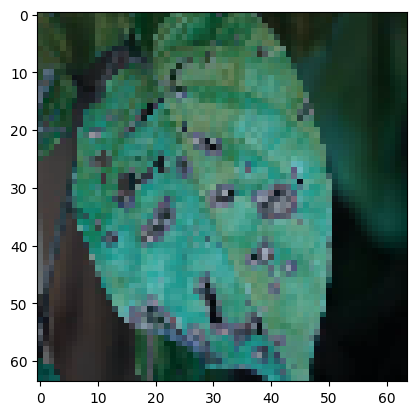

In [18]:
test_img = cv2.imread('test.jpg')
test_img = cv2.resize(test_img, img_size)
test_img = test_img /  255.0
test_img = np.reshape(test_img, (1, 64, 64, 3))

prediction = model.predict(test_img)
if prediction[0][0] > 0.5:
    print("Predicted Class: Class-2")
else:    print("Predicted Class: Class-1")
plt.imshow(test_img[0])